# EXP029: MLE RMSE comparison — DQN vs MFI

正値制約を外したEXP029のDQNと、EXP027のPython notebookで生成したMFIを
MLE推定に限定して比較します。

- シミュレーション: `data/uncorrelated_banks/item_bank_uncor_1.csv`
- 実データ: `data/LNIRT_CredentialForm1/`
- MFI: EXP027のPython生成summary CSV
- DQN（シミュレーション）: 通常DQNとDQN-Param-Rawについて、normal/uniformともに
  gamma=0.1固定
- DQN（実データ）: EXP029で見つかったすべてのgammaのsummary CSV

実データとシミュレーションデータではRMSEのスケールが異なるため、2パネルの
Y軸は共有しません。


In [21]:
from __future__ import annotations

import re
from pathlib import Path

import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import numpy as np
import pandas as pd


def find_project_root() -> Path:
    cwd = Path.cwd().resolve()
    for root in [cwd, *cwd.parents]:
        if (root / "data").is_dir() and (root / "EXP029").is_dir():
            return root
    raise FileNotFoundError("Run this notebook inside the repository.")


ROOT = find_project_root()
EXP027_RESULTS = ROOT / "EXP027" / "results"
EXP029_RESULTS = ROOT / "EXP029" / "results"

BANK_ID = 1
REAL_DATASET = "LNIRT_CredentialForm1"
TEST_LENGTH = 40
KEY_STEPS = [10, 20, 30, 40]
DQN_PRIORS = ("normal", "uniform")
SIMULATED_GAMMA = "0.1"
PARAM_RAW_SEED = 42

print(f"Project root   : {ROOT}")
print(f"EXP027 MFI dir : {EXP027_RESULTS}")
print(f"EXP029 DQN dir : {EXP029_RESULTS}")

Project root   : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History
EXP027 MFI dir : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP027/results
EXP029 DQN dir : /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP029/results


In [22]:
REQUIRED_COLUMNS = {"step", "RMSE"}


def read_summary(path: Path) -> pd.DataFrame:
    if not path.exists():
        raise FileNotFoundError(f"Required summary CSV not found: {path}")
    frame = pd.read_csv(path)
    missing = REQUIRED_COLUMNS - set(frame.columns)
    if missing:
        raise ValueError(f"{path.name} is missing columns: {sorted(missing)}")

    frame = frame.copy()
    frame["step"] = frame["step"].round().astype(int)
    if frame["step"].duplicated().any():
        raise ValueError(f"{path.name} contains duplicate step values.")
    expected_steps = set(range(1, TEST_LENGTH + 1))
    if set(frame["step"]) != expected_steps:
        raise ValueError(
            f"{path.name} must contain exactly steps 1 through {TEST_LENGTH}."
        )
    if not np.isfinite(frame["RMSE"]).all():
        raise ValueError(f"{path.name} contains non-finite RMSE values.")
    return frame.sort_values("step").reset_index(drop=True)


DqnRunKey = tuple[str | None, str]


def gamma_sort_key(gamma: str) -> tuple[int, float | str]:
    try:
        return (0, float(gamma))
    except ValueError:
        return (1, gamma)


def mean_rmse(frame: pd.DataFrame) -> float:
    return float(frame["RMSE"].mean())


def select_gamma_by_prior(
    runs: dict[DqnRunKey, pd.DataFrame],
    gamma: str,
) -> dict[DqnRunKey, pd.DataFrame]:
    selected = {}
    for prior in DQN_PRIORS:
        key = (prior, gamma)
        if key not in runs:
            raise FileNotFoundError(
                f"No EXP029 simulated DQN MLE summary for prior={prior}, gamma={gamma}."
            )
        selected[key] = runs[key]
    return selected


def load_dqn_runs(
    pattern: str, regex: re.Pattern[str]
) -> dict[DqnRunKey, pd.DataFrame]:
    runs = {}
    for path in sorted(EXP029_RESULTS.glob(pattern)):
        match = regex.fullmatch(path.name)
        if match is not None:
            key = (match.groupdict().get("prior"), match.group("gamma"))
            if key in runs:
                raise ValueError(f"Duplicate EXP029 DQN run for {key}: {path}")
            runs[key] = read_summary(path)
    if not runs:
        raise FileNotFoundError(f"No EXP029 DQN MLE summaries matched {pattern!r}.")
    return runs


# Both MFI files are generated by Python notebooks in EXP027.
simulated_mfi_path = EXP027_RESULTS / f"summary_uncor_{BANK_ID}_MFI_MLE_python.csv"
real_mfi_path = EXP027_RESULTS / f"summary_real_{REAL_DATASET}_MFI_MLE.csv"

simulated_dqn_pattern = re.compile(
    rf"summary_uncor_{BANK_ID}_DQN_MLE_"
    rf"(?P<prior>{'|'.join(DQN_PRIORS)})_gamma_(?P<gamma>.+)\.csv"
)
simulated_param_raw_pattern = re.compile(
    rf"summary_uncor_{BANK_ID}_DQN_Param_Raw_MLE_"
    rf"(?P<prior>{'|'.join(DQN_PRIORS)})_gamma_(?P<gamma>.+)"
    rf"_seed_{PARAM_RAW_SEED}\.csv"
)
real_dqn_pattern = re.compile(
    rf"summary_real_{re.escape(REAL_DATASET)}_DQN_MLE_gamma_(?P<gamma>.+)\.csv"
)

simulated_dqn_all = load_dqn_runs(
    f"summary_uncor_{BANK_ID}_DQN_MLE_*_gamma_*.csv",
    simulated_dqn_pattern,
)
loaded_simulated_priors = {prior for prior, _ in simulated_dqn_all}
missing_priors = set(DQN_PRIORS) - loaded_simulated_priors
if missing_priors:
    raise FileNotFoundError(
        "Missing EXP029 simulated DQN MLE summaries for prior(s): "
        f"{sorted(missing_priors)}"
    )

simulated_dqn = select_gamma_by_prior(simulated_dqn_all, SIMULATED_GAMMA)

simulated_param_raw_all = load_dqn_runs(
    (f"summary_uncor_{BANK_ID}_DQN_Param_Raw_MLE_*_gamma_*_seed_{PARAM_RAW_SEED}.csv"),
    simulated_param_raw_pattern,
)
loaded_param_raw_priors = {prior for prior, _ in simulated_param_raw_all}
missing_param_raw_priors = set(DQN_PRIORS) - loaded_param_raw_priors
if missing_param_raw_priors:
    raise FileNotFoundError(
        "Missing EXP029 simulated DQN-Param-Raw MLE summaries for prior(s): "
        f"{sorted(missing_param_raw_priors)}"
    )
simulated_param_raw = select_gamma_by_prior(simulated_param_raw_all, SIMULATED_GAMMA)

real_dqn = load_dqn_runs(
    f"summary_real_{REAL_DATASET}_DQN_MLE_gamma_*.csv",
    real_dqn_pattern,
)

comparisons = {
    "Simulated responses": {
        "subtitle": (
            f"uncorrelated bank {BANK_ID}\n"
            f"gamma={SIMULATED_GAMMA} for normal and uniform"
        ),
        "mfi": read_summary(simulated_mfi_path),
        "mfi_path": simulated_mfi_path,
        "dqn": simulated_dqn,
        "dqn_param_raw": simulated_param_raw,
    },
    "Real responses": {
        "subtitle": REAL_DATASET,
        "mfi": read_summary(real_mfi_path),
        "mfi_path": real_mfi_path,
        "dqn": real_dqn,
        "dqn_param_raw": {},
    },
}

for name, comparison in comparisons.items():
    print(f"{name}:")
    print(f"  MFI (EXP027 Python): {comparison['mfi_path'].name}")
    run_groups = (
        ("DQN", comparison["dqn"]),
        ("DQN-Param-Raw", comparison["dqn_param_raw"]),
    )
    for model_name, runs in run_groups:
        for prior, gamma in sorted(runs):
            prior_text = f", prior={prior}" if prior is not None else ""
            average_text = (
                f", mean RMSE(step 1-40)={mean_rmse(runs[(prior, gamma)]):.6f}"
                if prior is not None
                else ""
            )
            print(f"  {model_name} (EXP029): gamma={gamma}{prior_text}{average_text}")

Simulated responses:
  MFI (EXP027 Python): summary_uncor_1_MFI_MLE_python.csv
  DQN (EXP029): gamma=0.1, prior=normal, mean RMSE(step 1-40)=0.528594
  DQN (EXP029): gamma=0.1, prior=uniform, mean RMSE(step 1-40)=0.534375
  DQN-Param-Raw (EXP029): gamma=0.1, prior=normal, mean RMSE(step 1-40)=0.530034
  DQN-Param-Raw (EXP029): gamma=0.1, prior=uniform, mean RMSE(step 1-40)=0.534757
Real responses:
  MFI (EXP027 Python): summary_real_LNIRT_CredentialForm1_MFI_MLE.csv
  DQN (EXP029): gamma=0.1
  DQN (EXP029): gamma=0.3


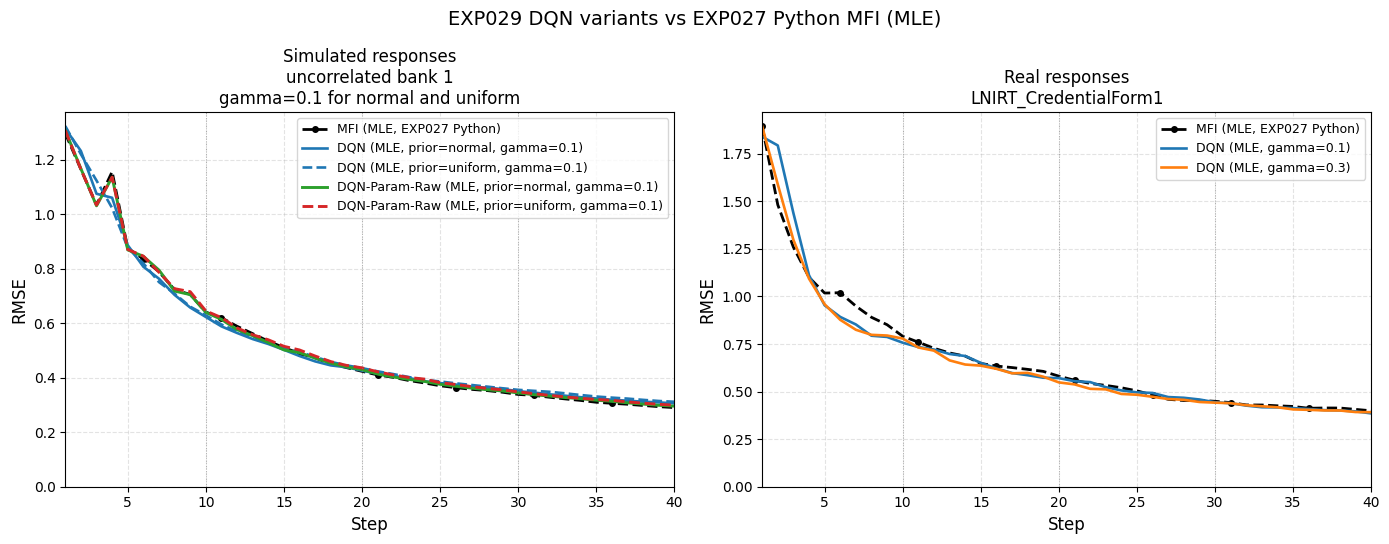

Saved comparison figure to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP029/results/rmse_comparison_MLE_simulated_and_real.png


In [23]:
def dqn_sort_key(key: DqnRunKey) -> tuple[int, tuple[int, float | str]]:
    prior, gamma = key
    prior_order = DQN_PRIORS.index(prior) if prior in DQN_PRIORS else len(DQN_PRIORS)
    return (prior_order, gamma_sort_key(gamma))


def dqn_label(prior: str | None, gamma: str) -> str:
    prior_text = f", prior={prior}" if prior is not None else ""
    return f"DQN (MLE{prior_text}, gamma={gamma})"


def param_raw_label(prior: str, gamma: str) -> str:
    return f"DQN-Param-Raw (MLE, prior={prior}, gamma={gamma})"


def draw_panel(axis, title: str, comparison: dict) -> None:
    mfi = comparison["mfi"]
    axis.plot(
        mfi["step"],
        mfi["RMSE"],
        color="black",
        linestyle="--",
        marker="o",
        markevery=5,
        markersize=4,
        linewidth=2.0,
        label="MFI (MLE, EXP027 Python)",
    )

    run_keys = sorted(comparison["dqn"], key=dqn_sort_key)
    gammas = sorted({gamma for _, gamma in run_keys}, key=gamma_sort_key)
    colors = {gamma: plt.get_cmap("tab10")(index) for index, gamma in enumerate(gammas)}
    for prior, gamma in run_keys:
        curve = comparison["dqn"][(prior, gamma)]
        axis.plot(
            curve["step"],
            curve["RMSE"],
            color=colors[gamma],
            linestyle="--" if prior == "uniform" else "-",
            linewidth=1.9,
            label=dqn_label(prior, gamma),
        )

    param_raw_colors = {"normal": "tab:green", "uniform": "tab:red"}
    for prior, gamma in sorted(comparison["dqn_param_raw"], key=dqn_sort_key):
        if prior is None:
            raise ValueError("DQN-Param-Raw run must specify its prior.")
        curve = comparison["dqn_param_raw"][(prior, gamma)]
        axis.plot(
            curve["step"],
            curve["RMSE"],
            color=param_raw_colors[prior],
            linestyle="--" if prior == "uniform" else "-",
            linewidth=2.1,
            label=param_raw_label(prior, gamma),
        )

    for step in KEY_STEPS:
        axis.axvline(
            step,
            color="gray",
            linewidth=0.7,
            linestyle=":",
            alpha=0.6,
        )

    axis.set_title(f"{title}\n{comparison['subtitle']}", fontsize=12)
    axis.set_xlabel("Step", fontsize=12)
    axis.set_ylabel("RMSE", fontsize=12)
    axis.set_xlim(1, TEST_LENGTH)
    axis.set_ylim(bottom=0)
    axis.xaxis.set_major_locator(mticker.MultipleLocator(5))
    axis.grid(True, linestyle="--", alpha=0.35)
    axis.legend(fontsize=9)


figure, axes = plt.subplots(
    1,
    len(comparisons),
    figsize=(14, 5.5),
    squeeze=False,
    sharey=False,
)
for axis, (title, comparison) in zip(axes[0], comparisons.items()):
    draw_panel(axis, title, comparison)

figure.suptitle(
    "EXP029 DQN variants vs EXP027 Python MFI (MLE)",
    fontsize=14,
)
figure.tight_layout()
EXP029_RESULTS.mkdir(parents=True, exist_ok=True)
combined_path = EXP029_RESULTS / "rmse_comparison_MLE_simulated_and_real.png"
figure.savefig(combined_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved comparison figure to: {combined_path}")

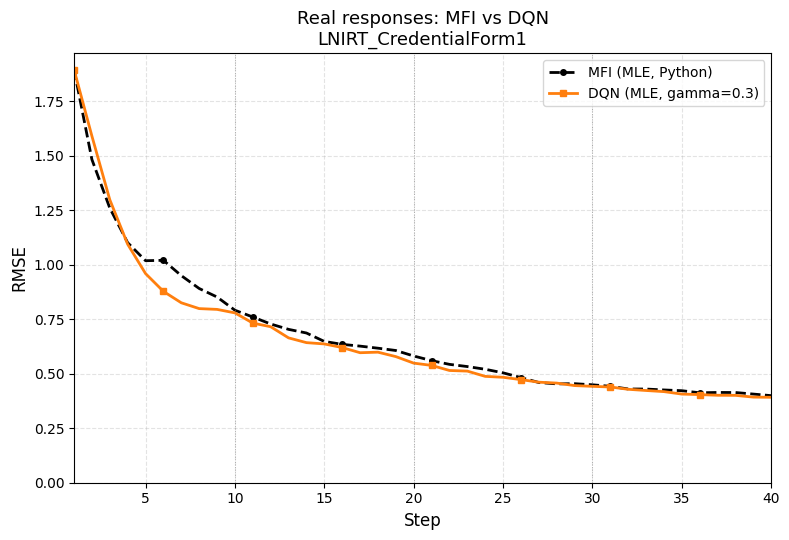

Saved real-response comparison figure to: /Users/itsuki/Adaptive-Testing-Based-on-Reinforcement-Learning-Considering-Response-History/EXP029/results/rmse_comparison_MLE_real_gamma_0.3.png


In [24]:
# Real-response comparison requested for MFI(MLE, Python) vs DQN(MLE, gamma=0.3).
REAL_GAMMA = "0.3"
real_comparison = comparisons["Real responses"]
real_run_key = (None, REAL_GAMMA)
if real_run_key not in real_comparison["dqn"]:
    raise FileNotFoundError(
        f"EXP029 real-response DQN summary for gamma={REAL_GAMMA} was not found."
    )

real_mfi = real_comparison["mfi"]
real_dqn_curve = real_comparison["dqn"][real_run_key]

real_figure, real_axis = plt.subplots(figsize=(8, 5.5))
real_axis.plot(
    real_mfi["step"],
    real_mfi["RMSE"],
    color="black",
    linestyle="--",
    marker="o",
    markevery=5,
    markersize=4,
    linewidth=2.0,
    label="MFI (MLE, Python)",
)
real_axis.plot(
    real_dqn_curve["step"],
    real_dqn_curve["RMSE"],
    color="tab:orange",
    marker="s",
    markevery=5,
    markersize=4,
    linewidth=2.0,
    label=f"DQN (MLE, gamma={REAL_GAMMA})",
)
for step in KEY_STEPS:
    real_axis.axvline(
        step,
        color="gray",
        linewidth=0.7,
        linestyle=":",
        alpha=0.6,
    )

real_axis.set_title(f"Real responses: MFI vs DQN\n{REAL_DATASET}", fontsize=13)
real_axis.set_xlabel("Step", fontsize=12)
real_axis.set_ylabel("RMSE", fontsize=12)
real_axis.set_xlim(1, TEST_LENGTH)
real_axis.set_ylim(bottom=0)
real_axis.xaxis.set_major_locator(mticker.MultipleLocator(5))
real_axis.grid(True, linestyle="--", alpha=0.35)
real_axis.legend(fontsize=10)

real_figure.tight_layout()
real_gamma_path = EXP029_RESULTS / f"rmse_comparison_MLE_real_gamma_{REAL_GAMMA}.png"
real_figure.savefig(real_gamma_path, dpi=150, bbox_inches="tight")
plt.show()
print(f"Saved real-response comparison figure to: {real_gamma_path}")

In [25]:
def rmse_at(frame: pd.DataFrame, step: int) -> float:
    return float(frame.loc[frame["step"] == step, "RMSE"].iloc[0])


rows = []
for data_name, comparison in comparisons.items():
    rows.append(
        {
            "data": data_name,
            "series": "MFI (MLE, EXP027 Python)",
            **{f"step_{step}": rmse_at(comparison["mfi"], step) for step in KEY_STEPS},
        }
    )
    for prior, gamma in sorted(comparison["dqn"], key=dqn_sort_key):
        rows.append(
            {
                "data": data_name,
                "series": dqn_label(prior, gamma),
                **{
                    f"step_{step}": rmse_at(comparison["dqn"][(prior, gamma)], step)
                    for step in KEY_STEPS
                },
            }
        )
    for prior, gamma in sorted(comparison["dqn_param_raw"], key=dqn_sort_key):
        if prior is None:
            raise ValueError("DQN-Param-Raw run must specify its prior.")
        rows.append(
            {
                "data": data_name,
                "series": param_raw_label(prior, gamma),
                **{
                    f"step_{step}": rmse_at(
                        comparison["dqn_param_raw"][(prior, gamma)], step
                    )
                    for step in KEY_STEPS
                },
            }
        )

key_step_comparison = pd.DataFrame(rows).set_index(["data", "series"])
print(key_step_comparison.to_string(float_format="{:.3f}".format))

                                                                   step_10  step_20  step_30  step_40
data                series                                                                           
Simulated responses MFI (MLE, EXP027 Python)                         0.641    0.424    0.339    0.291
                    DQN (MLE, prior=normal, gamma=0.1)               0.623    0.426    0.351    0.306
                    DQN (MLE, prior=uniform, gamma=0.1)              0.630    0.436    0.356    0.312
                    DQN-Param-Raw (MLE, prior=normal, gamma=0.1)     0.640    0.430    0.344    0.296
                    DQN-Param-Raw (MLE, prior=uniform, gamma=0.1)    0.645    0.436    0.349    0.299
Real responses      MFI (MLE, EXP027 Python)                         0.791    0.581    0.449    0.399
                    DQN (MLE, gamma=0.1)                             0.757    0.571    0.444    0.385
                    DQN (MLE, gamma=0.3)                             0.779    0.54